# Task 2: Multi-Modal Cardiac Image Fusion (CT + MRI)

Fuses a CT (`slice_001_ct.png`) and MRI (`slice_001_mri.png`) slice of the same cardiac cross-section via independent histogram equalization, false-color mapping, weighted blending, and log/gamma post-processing.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)

CT_PATH  = 'data/slice_001_ct.png'
MRI_PATH = 'data/slice_001_mri.png'

## Step 1: Load and Compare Raw Modalities

CT  shape: (256, 256)  | min=0, max=130, mean=61.0
MRI shape: (256, 256) | min=0, max=176, mean=55.3


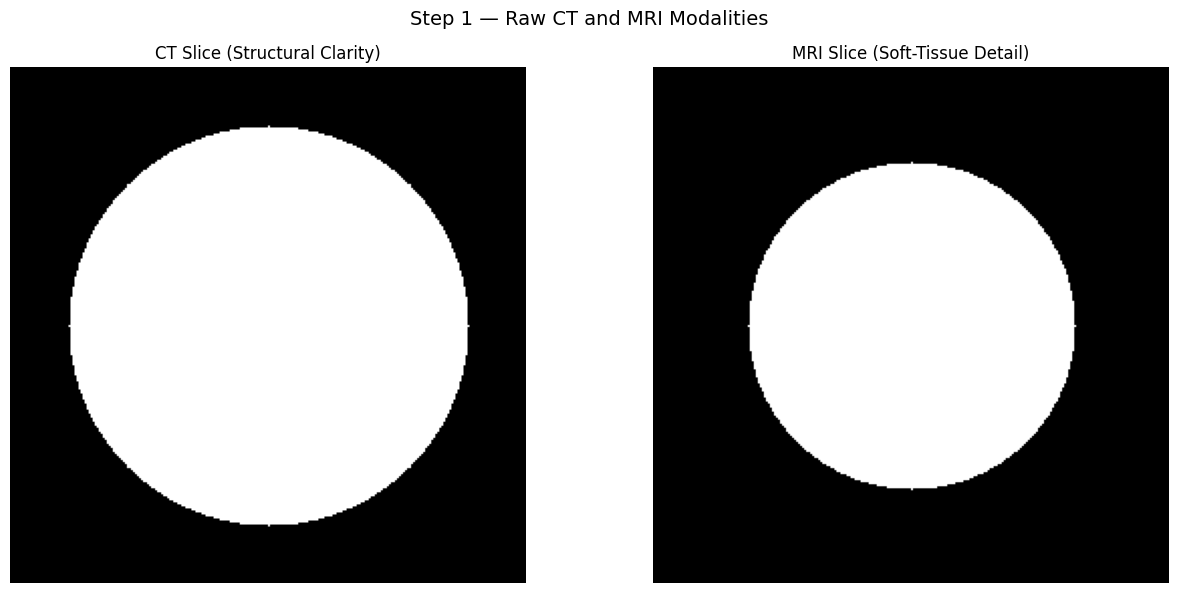

In [8]:
ct_raw  = cv2.imread(CT_PATH,  cv2.IMREAD_GRAYSCALE)
mri_raw = cv2.imread(MRI_PATH, cv2.IMREAD_GRAYSCALE)

if ct_raw.shape != mri_raw.shape:
    mri_raw = cv2.resize(mri_raw, (ct_raw.shape[1], ct_raw.shape[0]))
    print(f'MRI resized to match CT: {ct_raw.shape}')

print(f'CT  shape: {ct_raw.shape}  | min={ct_raw.min()}, max={ct_raw.max()}, mean={ct_raw.mean():.1f}')
print(f'MRI shape: {mri_raw.shape} | min={mri_raw.min()}, max={mri_raw.max()}, mean={mri_raw.mean():.1f}')

raw_side = np.hstack([ct_raw, mri_raw])
cv2.imwrite('output/01_ct_mri_raw.png', raw_side)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(ct_raw,  cmap='gray')
axes[0].set_title('CT Slice (Structural Clarity)', fontsize=12)
axes[0].axis('off')
axes[1].imshow(mri_raw, cmap='gray')
axes[1].set_title('MRI Slice (Soft-Tissue Detail)', fontsize=12)
axes[1].axis('off')
plt.suptitle('Step 1 — Raw CT and MRI Modalities', fontsize=14)
plt.tight_layout()
plt.show()

## Step 2: Histogram Equalization
Equalize CT and MRI independently to normalize their dynamic ranges before fusion.

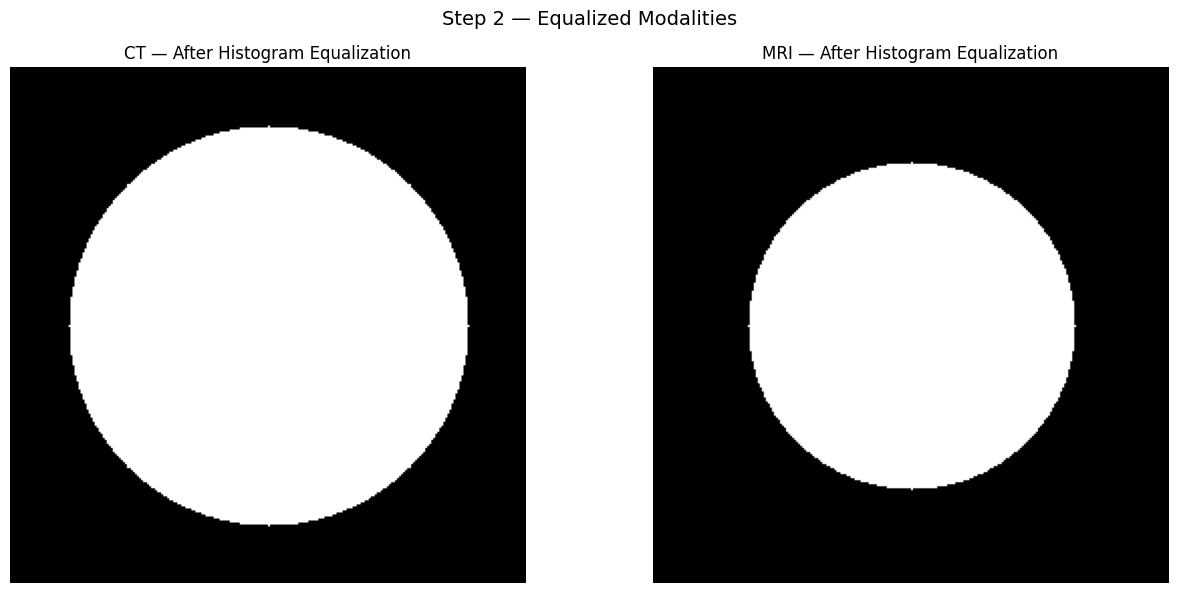

In [3]:
ct_eq  = cv2.equalizeHist(ct_raw)
mri_eq = cv2.equalizeHist(mri_raw)

eq_side = np.hstack([ct_eq, mri_eq])
cv2.imwrite('output/02_equalized_modalities.png', eq_side)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(ct_eq,  cmap='gray')
axes[0].set_title('CT — After Histogram Equalization')
axes[0].axis('off')
axes[1].imshow(mri_eq, cmap='gray')
axes[1].set_title('MRI — After Histogram Equalization')
axes[1].axis('off')
plt.suptitle('Step 2 — Equalized Modalities', fontsize=14)
plt.tight_layout()
plt.show()

## Step 3: False-Color Mapping
Map CT to `COLORMAP_BONE` and MRI to `COLORMAP_HOT` so both sources stay visually distinguishable once fused.

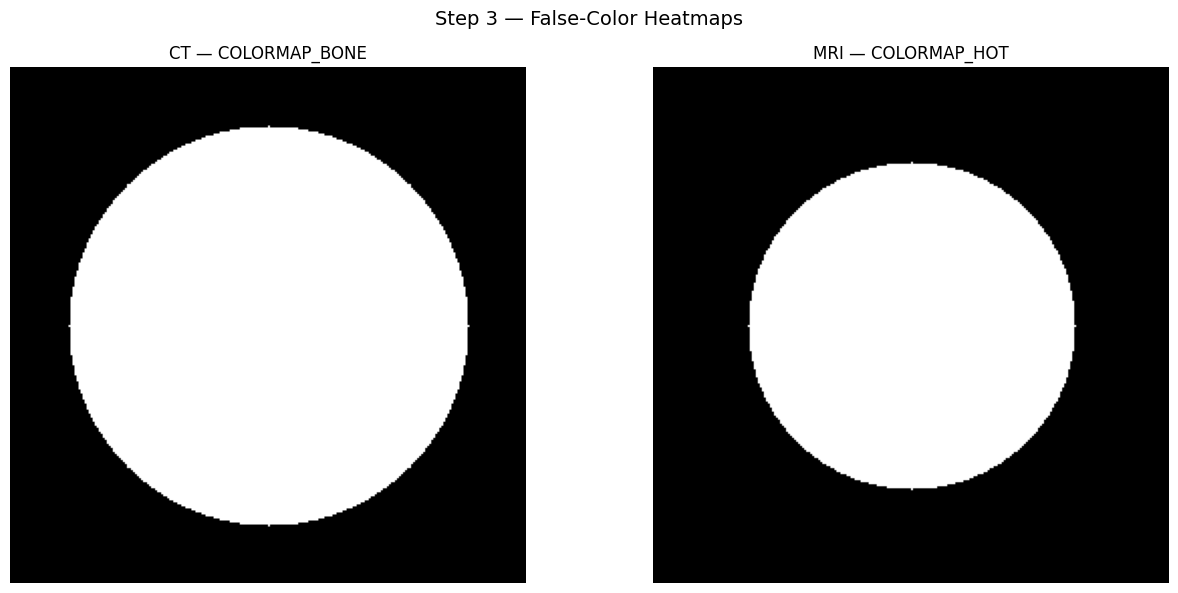

In [4]:
ct_colored  = cv2.applyColorMap(ct_eq,  cv2.COLORMAP_BONE)
mri_colored = cv2.applyColorMap(mri_eq, cv2.COLORMAP_HOT)

colored_side = np.hstack([ct_colored, mri_colored])
cv2.imwrite('output/03_colored_heatmaps.png', colored_side)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(cv2.cvtColor(ct_colored,  cv2.COLOR_BGR2RGB))
axes[0].set_title('CT — COLORMAP_BONE', fontsize=12)
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(mri_colored, cv2.COLOR_BGR2RGB))
axes[1].set_title('MRI — COLORMAP_HOT', fontsize=12)
axes[1].axis('off')
plt.suptitle('Step 3 — False-Color Heatmaps', fontsize=14)
plt.tight_layout()
plt.show()

## Step 4: Weighted Fusion
Blend the colored heatmaps with `cv2.addWeighted()`: $I_{fused} = 0.65 \cdot I_{CT} + 0.35 \cdot I_{MRI}$.

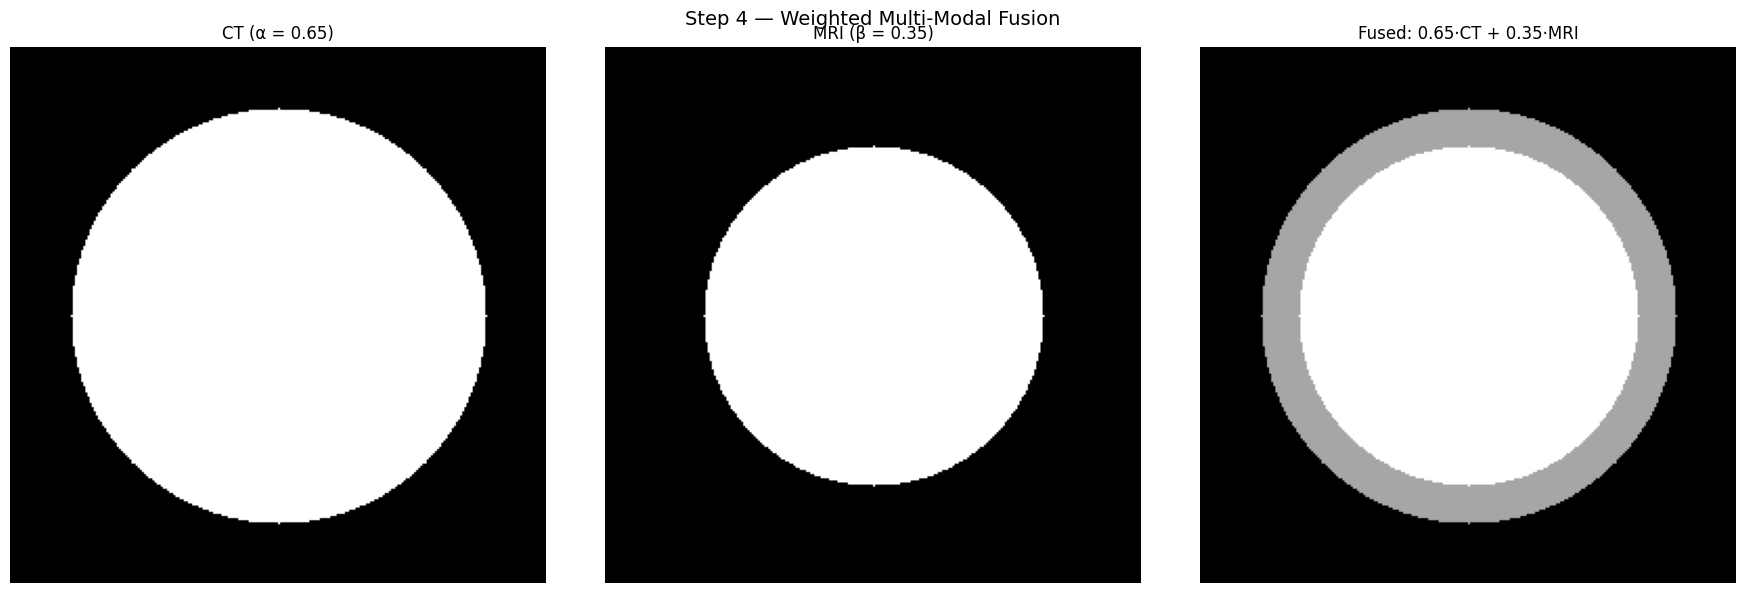

In [5]:
alpha, beta, gamma_offset = 0.65, 0.35, 0

img_fused = cv2.addWeighted(ct_colored, alpha, mri_colored, beta, gamma_offset)
cv2.imwrite('output/04_weighted_fusion.png', img_fused)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(ct_colored,  cv2.COLOR_BGR2RGB))
axes[0].set_title(f'CT (α = {alpha})')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(mri_colored, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'MRI (β = {beta})')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img_fused,   cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Fused: {alpha}·CT + {beta}·MRI')
axes[2].axis('off')
plt.suptitle('Step 4 — Weighted Multi-Modal Fusion', fontsize=14)
plt.tight_layout()
plt.show()

## Step 5: Log and Power-Law Transform
Apply a log transform to recover shadow detail, then a gamma transform ($\gamma = 0.8$) to balance midtones.

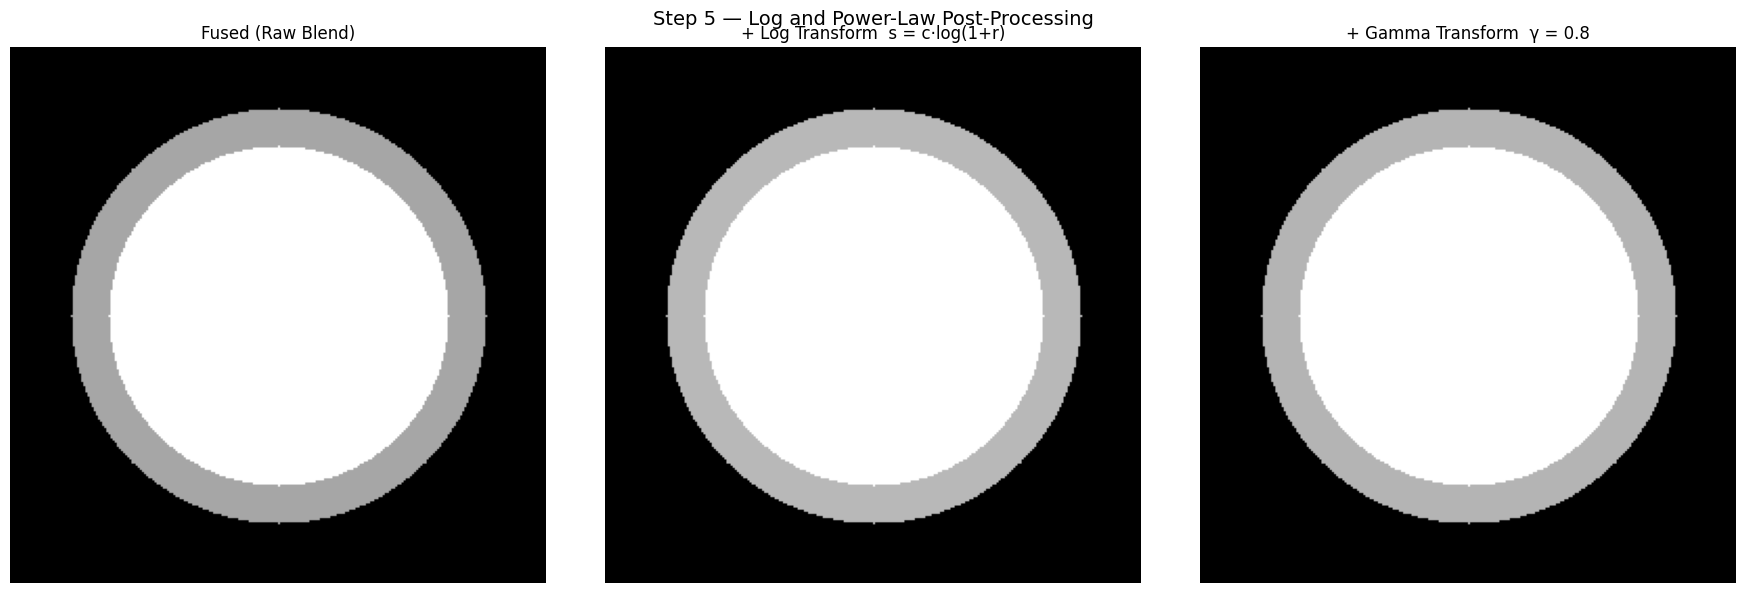

In [6]:
fused_f = img_fused.astype(np.float32) / 255.0
c_log   = 1.0 / np.log(1 + 1.0)
img_log_fused = np.clip(c_log * np.log(1 + fused_f) * 255, 0, 255).astype(np.uint8)

gamma_val = 0.8
img_gamma_fused = np.clip(np.power(fused_f, gamma_val) * 255, 0, 255).astype(np.uint8)

post_side = np.hstack([img_fused, img_log_fused, img_gamma_fused])
cv2.imwrite('output/05_log_and_power_law_fusion.png', post_side)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(img_fused,       cv2.COLOR_BGR2RGB))
axes[0].set_title('Fused (Raw Blend)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_log_fused,   cv2.COLOR_BGR2RGB))
axes[1].set_title('+ Log Transform  s = c·log(1+r)')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img_gamma_fused, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'+ Gamma Transform  γ = {gamma_val}')
axes[2].axis('off')
plt.suptitle('Step 5 — Log and Power-Law Post-Processing', fontsize=14)
plt.tight_layout()
plt.show()

## Step 6: Comparison Dashboard
Side-by-side view of all 6 stages.

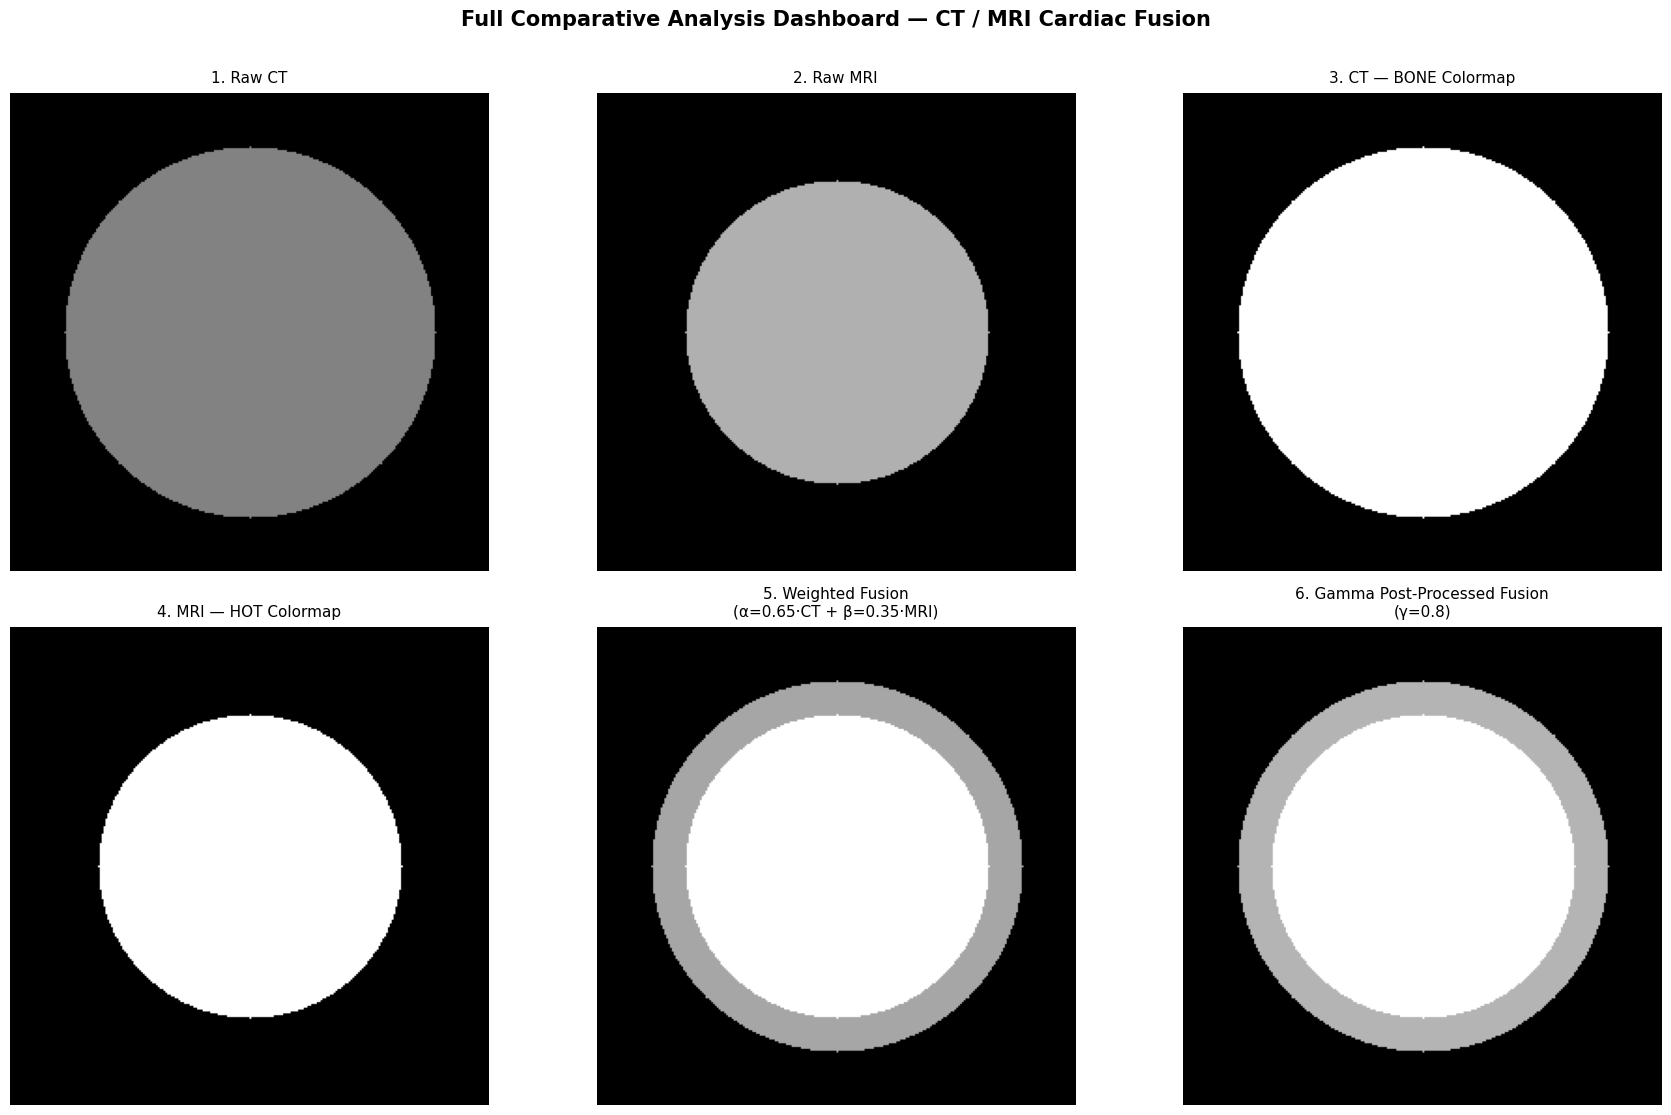

In [7]:
def to_rgb(img):
    if len(img.shape) == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

stages = [
    ('1. Raw CT',                    ct_raw),
    ('2. Raw MRI',                   mri_raw),
    ('3. CT — BONE Colormap',        ct_colored),
    ('4. MRI — HOT Colormap',        mri_colored),
    ('5. Weighted Fusion\n(α=0.65·CT + β=0.35·MRI)', img_fused),
    ('6. Gamma Post-Processed Fusion\n(γ=0.8)',       img_gamma_fused),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (title, img) in enumerate(stages):
    axes[i].imshow(to_rgb(img))
    axes[i].set_title(title, fontsize=11, pad=8)
    axes[i].axis('off')

plt.suptitle('Full Comparative Analysis Dashboard — CT / MRI Cardiac Fusion', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/06_comparative_analysis_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()